# Отчет по лабораторной работе №3
## Тема: Регрессия - предсказание цены подержанного автомобиля с использованием метода K-ближайших соседей

### Описание задания
**Цель:** изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.
### Задание включает следующие пункты:
1. Выбрать набор данных для решения задачи классификации или регрессии
2. При необходимости провести удаление или заполнение пропусков и кодирование категориальных признаков
3. С использованием метода `train_test_split` разделить выборку на обучающую и тестовую
4. Обучить модель ближайших соседей для произвольно заданного гиперпараметра K, оценить качество модели с помощью подходящих метрик
5. Произвести подбор гиперпараметра K с использованием `GridSearchCV` и `RandomizedSearchCV` и кросс-валидации, используя не менее двух стратегий кросс-валидации
6. Сравнить метрики качества исходной и оптимальной моделей

### Датасет
**Название:** Used Car Price Prediction Dataset
Датасет содержит объявления о продаже подержанных автомобилей с американского рынка. 
Каждая строка — одно объявление о продаже конкретного автомобиля.

**Источник:** https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset?resource=download

| Признак | Тип | Описание |
|---|---|---|
| `brand` | категориальный | Марка автомобиля (Ford, Toyota, BMW...) |
| `model` | категориальный | Модель автомобиля |
| `model_year` | числовой | Год выпуска |
| `milage` | числовой | Пробег (в милях) |
| `fuel_type` | категориальный | Тип топлива (Gasoline, Hybrid, Electric...) |
| `engine` | текстовый | Описание двигателя — извлекаем мощность в л.с. |
| `transmission` | категориальный | Тип трансмиссии (Automatic, Manual...) |
| `ext_col` | категориальный | Цвет кузова |
| `int_col` | категориальный | Цвет салона |
| `accident` | категориальный | Наличие аварий в истории |
| `clean_title` | категориальный | Чистота юридического титула |
| `price` | числовой | **Целевая переменная** — цена в долларах США |

### 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Загрузка и первичный осмотр данных

In [2]:
df = pd.read_csv('used_cars.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (4009, 12)

Первые 5 строк:


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
print("Информация о датасете:")
df.info()

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [4]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


### 3. Предобработка данных

In [5]:
# Убираем символы и переводим в числа
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['milage'] = df['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False).astype(float)
print(df[['price', 'milage']].describe())

              price         milage
count  4.009000e+03    4009.000000
mean   4.455319e+04   64717.551010
std    7.871064e+04   52296.599459
min    2.000000e+03     100.000000
25%    1.720000e+04   23044.000000
50%    3.100000e+04   52775.000000
75%    4.999000e+04   94100.000000
max    2.954083e+06  405000.000000


In [6]:
# В колонке engine есть паттерн "300.0HP" — извлекаем число перед HP
df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
# Проверим сколько удалось извлечь
print("Пропусков в horsepower:", df['horsepower'].isna().sum())
print(df['horsepower'].describe())

Пропусков в horsepower: 808
count    3201.000000
mean      332.206498
std       122.258492
min        70.000000
25%       248.000000
50%       310.000000
75%       400.000000
max      1020.000000
Name: horsepower, dtype: float64


Пропуски заполним модой и медианой

In [9]:
# Заполняем пропуски
for col in ['fuel_type', 'accident', 'clean_title']:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)
    print(f"{col}: заполнено значением '{moda}'")

df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

print("\nПропуски после заполнения:")
print(df.isnull().sum())

fuel_type: заполнено значением '2'
accident: заполнено значением '1'
clean_title: заполнено значением '0'

Пропуски после заполнения:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
horsepower      0
dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['brand', 'model', 'fuel_type', 'transmission', 
            'ext_col', 'int_col', 'accident', 'clean_title']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Готово! Типы данных после кодирования:")
print(df.dtypes)

Готово! Типы данных после кодирования:
brand             int64
model             int64
model_year        int64
milage          float64
fuel_type         int64
engine              str
transmission      int64
ext_col           int64
int_col           int64
accident          int64
clean_title       int64
price           float64
horsepower      float64
dtype: object


In [10]:
# Удаляем колонку engine — уже извлекли из неё horsepower
df = df.drop(columns=['engine'])

print("Итоговые колонки и типы:")
print(df.dtypes)
print("\nРазмер датасета:", df.shape)

Итоговые колонки и типы:
brand             int64
model             int64
model_year        int64
milage          float64
fuel_type         int64
transmission      int64
ext_col           int64
int_col           int64
accident          int64
clean_title       int64
price           float64
horsepower      float64
dtype: object

Размер датасета: (4009, 12)


### 4. Разделение на обучающую и тестовую выборки

In [11]:
from sklearn.model_selection import train_test_split

# Отделяем признаки от целевой переменной
X = df.drop(columns=['price'])  # всё кроме цены
y = df['price']                  # только цена

print("Размер X:", X.shape)
print("Размер y:", y.shape)

# Делим на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% уйдёт в тест
    random_state=42      # фиксируем случайность для воспроизводимости
)

print(f"\nОбучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка:  {X_test.shape[0]} строк")

Размер X: (4009, 11)
Размер y: (4009,)

Обучающая выборка: 3207 строк
Тестовая выборка:  802 строк


In [12]:
from sklearn.preprocessing import StandardScaler

# KNN считает расстояния — если milage в тысячах, 
# а model_year около 2015, то milage будет доминировать.
# StandardScaler приводит все признаки к одному масштабу.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # обучаем на train
X_test_scaled  = scaler.transform(X_test)        # применяем к test

print("Масштабирование выполнено")
print("Среднее по train (должно быть ~0):", X_train_scaled.mean().round(3))
print("Std по train (должно быть ~1):",     X_train_scaled.std().round(3))

Масштабирование выполнено
Среднее по train (должно быть ~0): 0.0
Std по train (должно быть ~1): 1.0


### 5. Базовая модель KNN (K=5)

In [13]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Создаём модель с K=5 (произвольное начальное значение)
knn = KNeighborsRegressor(n_neighbors=5)

# Обучаем на тренировочных данных
knn.fit(X_train_scaled, y_train)

# Предсказываем на тестовых данных
y_pred = knn.predict(X_test_scaled)

# Считаем метрики
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Базовая модель KNN (K=5) ===")
print(f"MAE:  {mae:.2f} $")
print(f"RMSE: {rmse:.2f} $")
print(f"R²:   {r2:.4f}")

=== Базовая модель KNN (K=5) ===
MAE:  25023.60 $
RMSE: 139885.21 $
R²:   0.0426


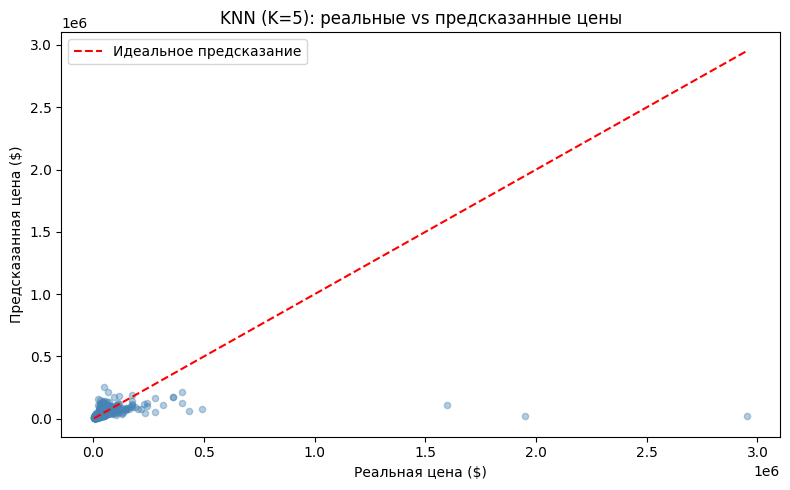

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=1.5, label='Идеальное предсказание')
plt.xlabel('Реальная цена ($)')
plt.ylabel('Предсказанная цена ($)')
plt.title('KNN (K=5): реальные vs предсказанные цены')
plt.legend()
plt.tight_layout()
plt.savefig('knn_baseline.png', dpi=150)
plt.show()

Распределение цен:
count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

Машин дороже $200k: 75
Машин дороже $100k: 234
Всего машин: 4009


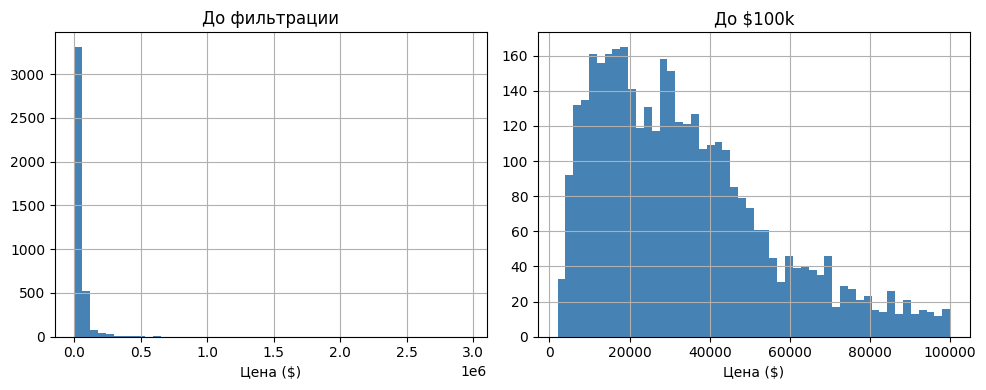

In [15]:
print("Распределение цен:")
print(df['price'].describe())
print(f"\nМашин дороже $200k: {(df['price'] > 200000).sum()}")
print(f"Машин дороже $100k: {(df['price'] > 100000).sum()}")
print(f"Всего машин: {len(df)}")

# Гистограмма цен
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['price'].hist(bins=50, color='steelblue')
plt.title('До фильтрации')
plt.xlabel('Цена ($)')

plt.subplot(1, 2, 2)
df[df['price'] < 100000]['price'].hist(bins=50, color='steelblue')
plt.title('До $100k')
plt.xlabel('Цена ($)')
plt.tight_layout()
plt.show()

In [16]:
# Оставляем только машины до $100k — это реалистичный рынок б/у авто
df_clean = df[df['price'] < 100000].copy()
print(f"Осталось строк: {len(df_clean)} (убрали {len(df) - len(df_clean)})")

# Заново делаем X, y, split, scaling
X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Заново обучаем KNN K=5
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("\n=== Базовая модель KNN (K=5) после фильтрации ===")
print(f"MAE:  {mae:.2f} $")
print(f"RMSE: {rmse:.2f} $")
print(f"R²:   {r2:.4f}")

Осталось строк: 3774 (убрали 235)

=== Базовая модель KNN (K=5) после фильтрации ===
MAE:  8619.05 $
RMSE: 12259.46 $
R²:   0.6683


### 6. Подбор гиперпараметра K с помощью кросс-валидации

In [17]:
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit

# Стратегия 1: KFold — делит данные на 5 равных частей
kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {'n_neighbors': list(range(1, 31))}  # проверяем K от 1 до 30

grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1,      # использовать все ядра процессора
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nGridSearchCV (KFold-5)")
print(f"Лучший K:  {grid_search.best_params_['n_neighbors']}")
print(f"Лучший R²: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

GridSearchCV (KFold-5)
Лучший K:  12
Лучший R²: 0.6500


In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Стратегия 2: ShuffleSplit — случайное разбиение, повторяется 10 раз
ss = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

param_dist = {'n_neighbors': randint(1, 51)}  # случайные K от 1 до 50

random_search = RandomizedSearchCV(
    KNeighborsRegressor(),
    param_dist,
    n_iter=20,          # проверяем 20 случайных значений
    cv=ss,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print(f"\nRandomizedSearchCV (ShuffleSplit-10)")
print(f"Лучший K:  {random_search.best_params_['n_neighbors']}")
print(f"Лучший R²: {random_search.best_score_:.4f}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits

RandomizedSearchCV (ShuffleSplit-10)
Лучший K:  8
Лучший R²: 0.6371


In [19]:
# Берём лучшую модель от GridSearchCV (K=12)
best_knn = grid_search.best_estimator_

y_pred_best = best_knn.predict(X_test_scaled)

mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best   = r2_score(y_test, y_pred_best)

print("=== Оптимальная модель KNN (K=12, GridSearchCV) ===")
print(f"MAE:  {mae_best:.2f} $")
print(f"RMSE: {rmse_best:.2f} $")
print(f"R²:   {r2_best:.4f}")

=== Оптимальная модель KNN (K=12, GridSearchCV) ===
MAE:  8611.46 $
RMSE: 12182.30 $
R²:   0.6724


### 7. Оценка оптимальной модели и сравнение результатов

In [20]:
print("=" * 45)
print(f"{'Метрика':<10} {'Базовая (K=5)':>15} {'Оптимальная (K=12)':>20}")
print("=" * 45)
print(f"{'MAE ($)':<10} {mae:>15.2f} {mae_best:>20.2f}")
print(f"{'RMSE ($)':<10} {rmse:>15.2f} {rmse_best:>20.2f}")
print(f"{'R²':<10} {r2:>15.4f} {r2_best:>20.4f}")
print("=" * 45)

улучшение = (r2_best - r2) / r2 * 100
print(f"\nУлучшение R²: +{улучшение:.1f}%")

Метрика      Базовая (K=5)   Оптимальная (K=12)
MAE ($)            8619.05              8611.46
RMSE ($)          12259.46             12182.30
R²                  0.6683               0.6724

Улучшение R²: +0.6%


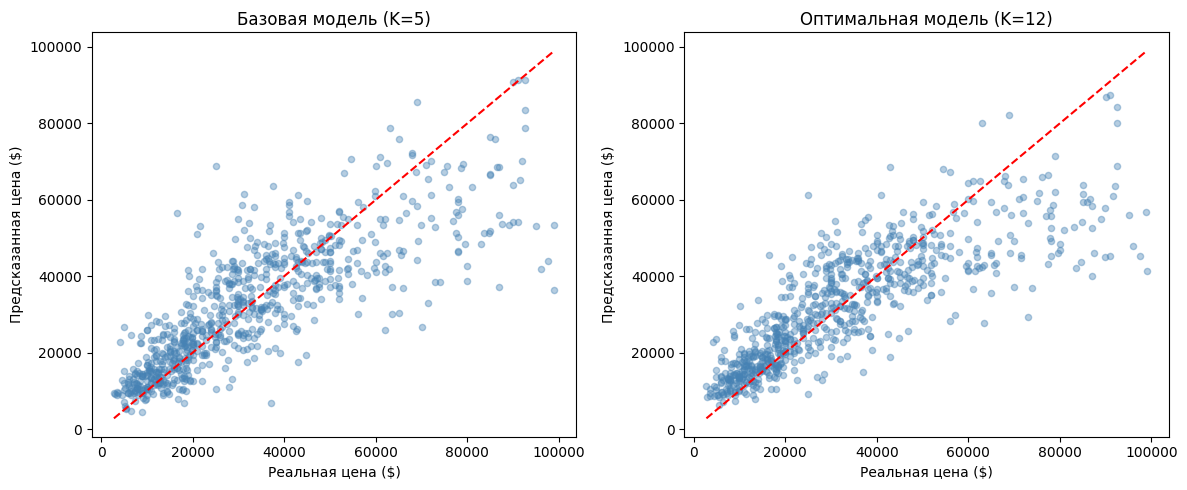

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [y_pred, y_pred_best],
    ['Базовая модель (K=5)', 'Оптимальная модель (K=12)']
):
    ax.scatter(y_test, preds, alpha=0.4, color='steelblue', s=20)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=1.5)
    ax.set_xlabel('Реальная цена ($)')
    ax.set_ylabel('Предсказанная цена ($)')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('knn_comparison.png', dpi=150)
plt.show()

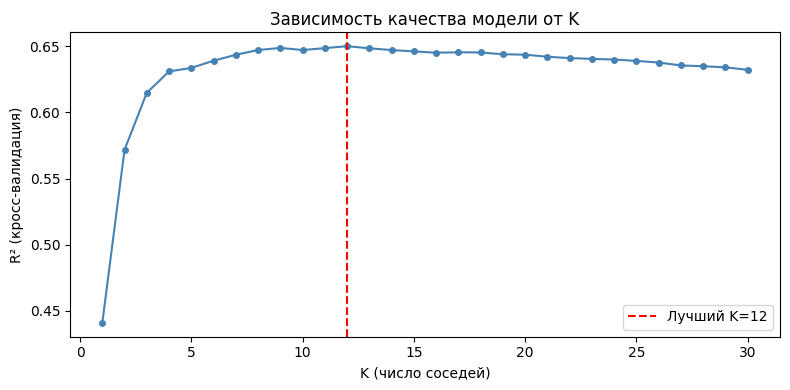

In [22]:
results = grid_search.cv_results_
ks  = results['param_n_neighbors'].data
r2s = results['mean_test_score']

plt.figure(figsize=(8, 4))
plt.plot(ks, r2s, marker='o', markersize=4, color='steelblue')
plt.axvline(x=12, color='red', linestyle='--', label='Лучший K=12')
plt.xlabel('K (число соседей)')
plt.ylabel('R² (кросс-валидация)')
plt.title('Зависимость качества модели от K')
plt.legend()
plt.tight_layout()
plt.savefig('knn_k_search.png', dpi=150)
plt.show()